# Electricity cost in Madrid

**Purpose of this notebook:** 
Analyze Madrid 2024 electricity spot prices, compute and export hourly averages to `hourly_elec_average_prices.csv`, then perform day-type clustering to produce `hourly_elec_clustered_prices.csv` for subsequent optimization workflows.

In [72]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [73]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [74]:
df = pd.read_csv('Retail_prices_2024.csv', index_col='Date', parse_dates=True)

In [75]:
print(f"{len(df)} days of data, from {df.index[0].date()} to {df.index[-1].date()} (leap year)")

print("The first 5 days :")
print(df.head()) 

366 days of data, from 2024-01-01 to 2024-12-31 (leap year)
The first 5 days :
             00:00   01:00   02:00   03:00   04:00   05:00   06:00   07:00  \
Date                                                                         
2024-01-01  0.1015  0.0847  0.0814  0.0763  0.0750  0.0745  0.0750  0.0752   
2024-01-02  0.0691  0.0528  0.0261  0.0388  0.0337  0.0395  0.0671  0.0778   
2024-01-03  0.0296  0.0251  0.0251  0.0251  0.0251  0.0238  0.0271  0.0788   
2024-01-04  0.1359  0.1316  0.1230  0.1101  0.1060  0.1077  0.1313  0.1412   
2024-01-05  0.1305  0.1234  0.1189  0.1109  0.0987  0.1078  0.1164  0.1309   

             08:00   09:00   10:00   11:00   12:00   13:00   14:00   15:00  \
Date                                                                         
2024-01-01  0.0761  0.0748  0.0528  0.0259  0.0251  0.0236  0.0232  0.0283   
2024-01-02  0.0894  0.0900  0.0846  0.0874  0.0782  0.0757  0.0757  0.0731   
2024-01-03  0.0997  0.1062  0.1019  0.0936  0.0909  0.0915  0.

In [76]:
electricity_prices = df.values
electricity_prices = electricity_prices.astype(float)
print(electricity_prices.shape)
electricity_prices

(366, 24)


array([[0.1015, 0.0847, 0.0814, ..., 0.0973, 0.0814, 0.0745],
       [0.0691, 0.0528, 0.0261, ..., 0.0882, 0.0798, 0.072 ],
       [0.0296, 0.0251, 0.0251, ..., 0.165 , 0.1408, 0.1311],
       ...,
       [0.207 , 0.2026, 0.1991, ..., 0.227 , 0.2137, 0.2095],
       [0.201 , 0.1927, 0.1876, ..., 0.2337, 0.219 , 0.2068],
       [0.2054, 0.1978, 0.1958, ..., 0.2128, 0.2046, 0.1982]])

### General Analysis (average data)

Average annual price: 0.101 €/kWh
Maximum observed price: 0.267 €/kWh
Minimum observed price: 0.018 €/kWh

Evolution of the daily average price:


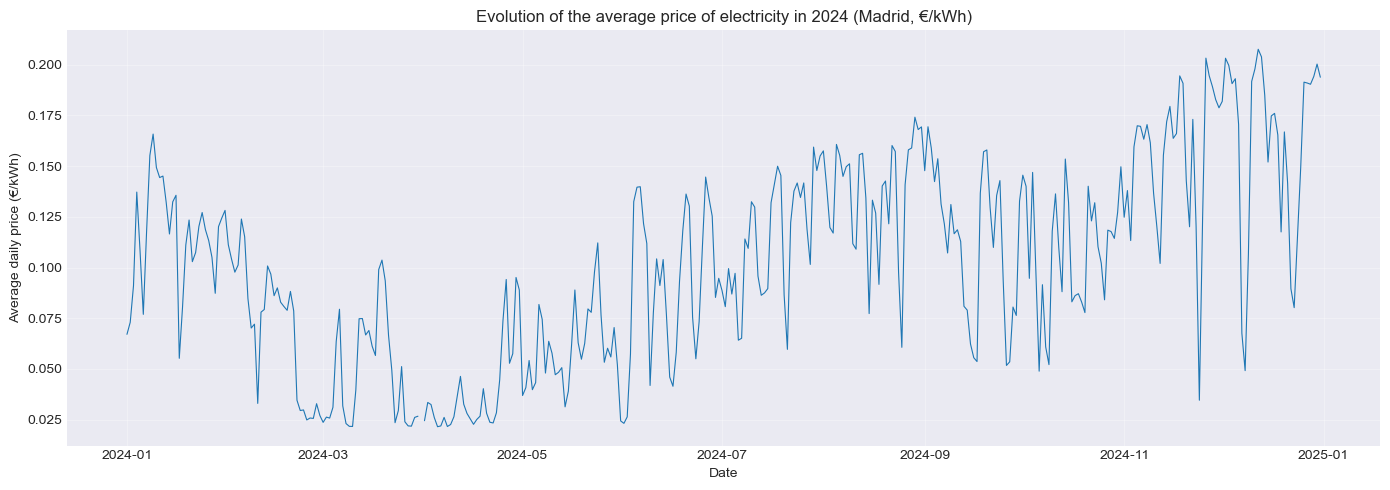

In [77]:
# Summary statistics
print(f"Average annual price: {np.nanmean(electricity_prices):.3f} €/kWh")
print(f"Maximum observed price: {np.nanmax(electricity_prices):.3f} €/kWh")
print(f"Minimum observed price: {np.nanmin(electricity_prices):.3f} €/kWh")

print("\nEvolution of the daily average price:")
plt.figure(figsize=(14, 5))

# Average price over each day (mean over the 24 hours)
average_daily_price = electricity_prices.mean(axis=1)
plt.plot(df.index[:], average_daily_price, linewidth=0.8)
plt.title('Evolution of the average price of electricity in 2024 (Madrid, €/kWh)')
plt.xlabel('Date')
plt.ylabel('Average daily price (€/kWh)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Average price per day (over 2024)


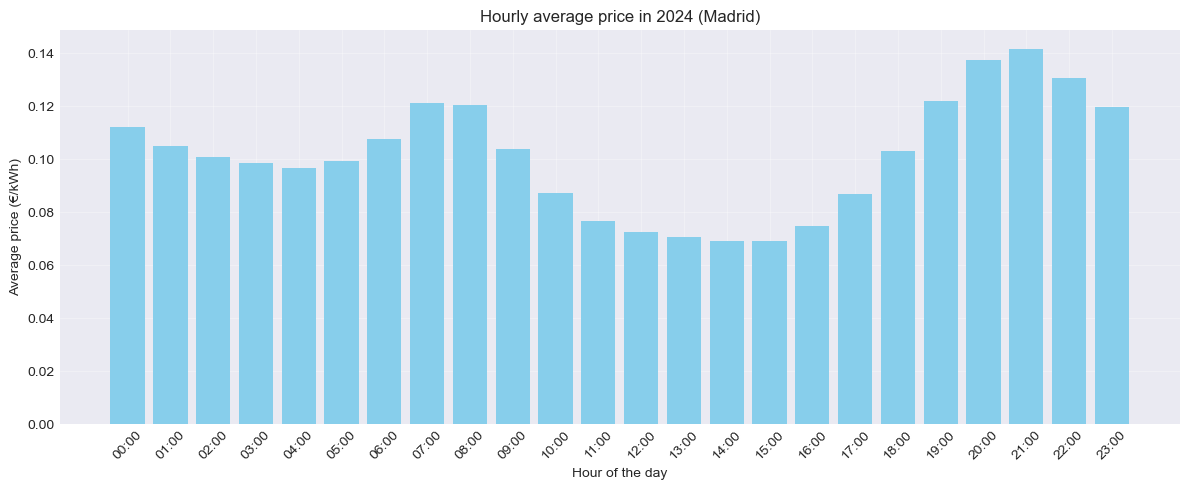

[0.11225137 0.10506175 0.10069617 0.09864399 0.09680847 0.0993418
 0.10781475 0.12128907 0.1204877  0.10401913 0.08712705 0.07652596
 0.07269399 0.07049208 0.06908115 0.06900656 0.07491967 0.08693525
 0.10305164 0.12217814 0.13742896 0.14160301 0.13080437 0.11963288]


In [78]:
# Average price per day (over the year)
print("Average price per day (over 2024)")
plt.figure(figsize=(12, 5))

average_hourly_price = np.nanmean(electricity_prices,axis=0)

hours = [h for h in df.columns] 
plt.bar(hours, average_hourly_price, color='skyblue')
plt.title('Hourly average price in 2024 (Madrid)')
plt.xlabel('Hour of the day')
plt.ylabel('Average price (€/kWh)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(average_hourly_price)

In [79]:
# Export the hourly average prices to a CSV file

# During all the hour h_i, the electricity market considers that the price of electricity is the same, 
# equal to the price at h_i:00 

# np.savetxt('hourly_elec_average_prices.csv', average_hourly_price.reshape(1, -1), delimiter=',', fmt='%.5f')

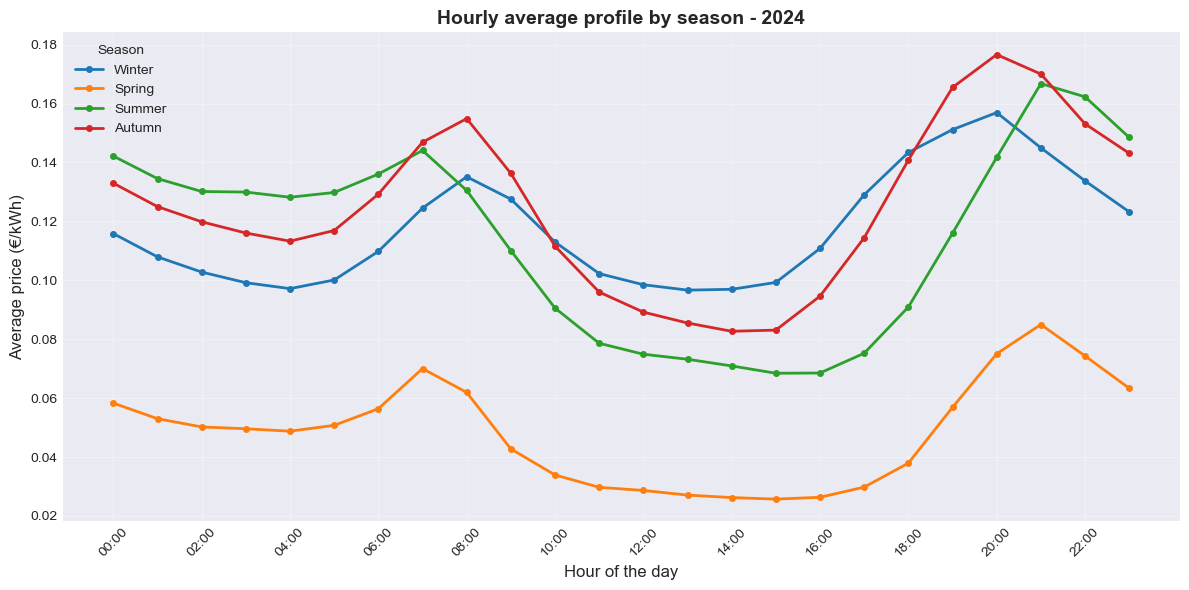


Average prices by season:
  Winter: 0.1175 €/kWh on average
    Peak at 20:00 (0.1569 €/kWh)
  Spring: 0.0484 €/kWh on average
    Peak at 21:00 (0.0850 €/kWh)
  Summer: 0.1143 €/kWh on average
    Peak at 21:00 (0.1668 €/kWh)
  Autumn: 0.1249 €/kWh on average
    Peak at 20:00 (0.1766 €/kWh)

Analysis of the outcomes:
Winter => cohensive high prices due to heating needs and lower renewable generation
Summer => unexpected high prices (for me) due to the demand for air conditioning which coincides with periods of low wind


In [80]:
# Seasonal analysis

def get_season(month):
    if month in [12, 1, 2]:  # Winter
        return 'Winter'
    elif month in [3, 4, 5]:  # Spring
        return 'Spring'
    elif month in [6, 7, 8]:  # Summer
        return 'Summer'
    else:  # Autumn
        return 'Autumn'

df['Season'] = df.index.month.map(get_season)
profils_season = df.groupby('Season').mean(numeric_only=True)
ordre_seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
profils_season = profils_season.reindex(ordre_seasons)


plt.figure(figsize=(12, 6))
for season in ordre_seasons:
    plt.plot(range(24), profils_season.loc[season].values, 
             label=season, linewidth=2, marker='o', markersize=4)

plt.title('Hourly average profile by season - 2024', fontsize=14, fontweight='bold')
plt.xlabel('Hour of the day', fontsize=12)
plt.ylabel('Average price (€/kWh)', fontsize=12)
plt.xticks(range(0, 24, 2), [f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title='Season', fontsize=10)
plt.tight_layout()
plt.show()

print("\nAverage prices by season:")
for season in ordre_seasons:
    avg_price = profils_season.loc[season].mean()
    heure_max = profils_season.loc[season].idxmax()
    prix_max = profils_season.loc[season].max()
    print(f"  {season}: {avg_price:.4f} €/kWh on average")
    print(f"    Peak at {heure_max} ({prix_max:.4f} €/kWh)")


print("\nAnalysis of the outcomes:")
print("Winter => cohensive high prices due to heating needs and lower renewable generation")
print("Summer => unexpected high prices (for me) due to the demand for air conditioning which coincides with periods of low wind")

### Clustered data

In [81]:
# Load clustering results
clustering_file_path = os.path.join('..', 'clustering_and_T', 'day_type_clustering.csv')
df_day_types = pd.read_csv(clustering_file_path, index_col='Date', parse_dates=True)
df_day_types.head()

,day_type
Date,
2024-01-01,Low
2024-01-02,Low
2024-01-03,Low
2024-01-04,Low
2024-01-05,Low


In [82]:
for i in range(24):
    df_day_types[i] = electricity_prices[:, i]

In [83]:
clustered_prices_expanded = df_day_types.groupby('day_type').mean(numeric_only=True)

# Export the hourly clustered prices to a CSV file

export_path = os.path.join('..', 'outputs_external_time_series', 'hourly_elec_clustered_prices.csv')

# During all the hour h_i, the electricity market considers that the price of electricity is the same, 
# equal to the price at h_i:00 

# clustered_prices_expanded.T.to_csv(export_path, 
#                 index=True, 
#                 index_label='day_type')

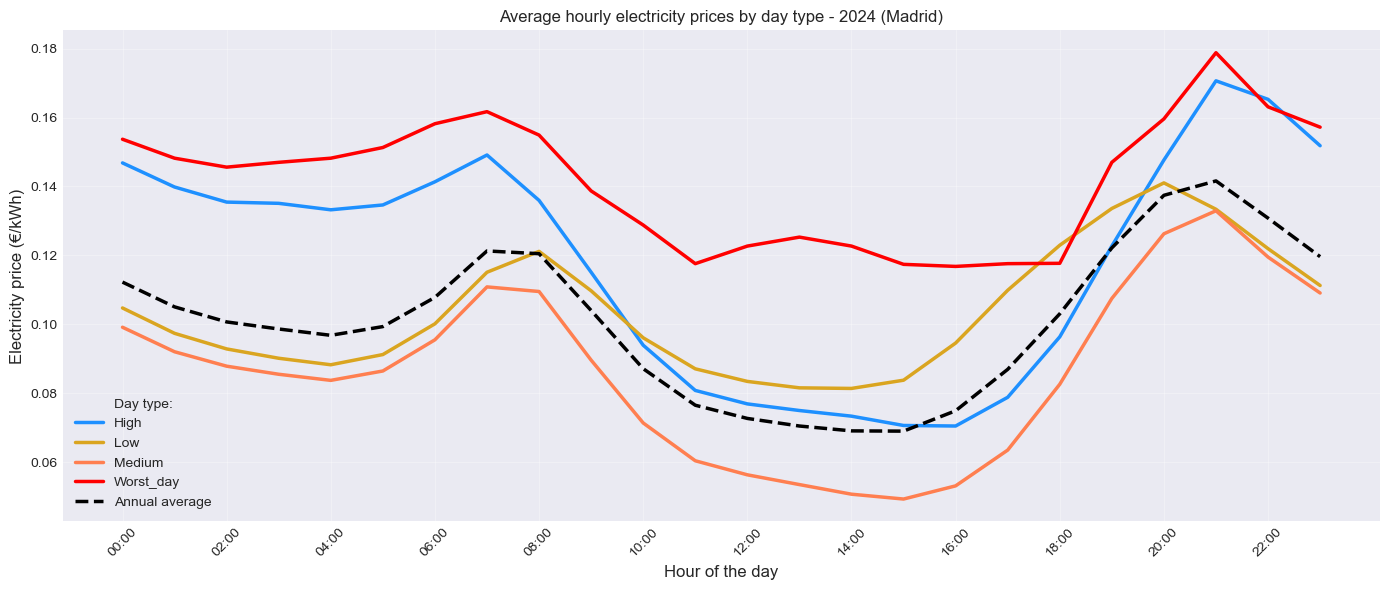

In [88]:
plt.figure(figsize=(14, 6))

colors = ['dodgerblue', 'goldenrod', 'coral', 'red']

for idx, day_type in enumerate(clustered_prices_expanded.index):
    plt.plot(range(24), clustered_prices_expanded.loc[day_type].values, 
             label=f'{day_type}', linewidth=2.5, color=colors[idx])

# Add the annual average price
plt.plot(range(24), average_hourly_price, 
         label='Annual average', linewidth=2.5, 
         color='black', linestyle='--')

plt.title('Average hourly electricity prices by day type - 2024 (Madrid)')
plt.xlabel('Hour of the day', fontsize=12)
plt.ylabel('Electricity price (€/kWh)', fontsize=12)
plt.xticks(range(0, 24, 2), [f'{h:02d}:00' for h in range(0, 24, 2)], rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title='Day type:', fontsize=10)
plt.tight_layout()
plt.show()

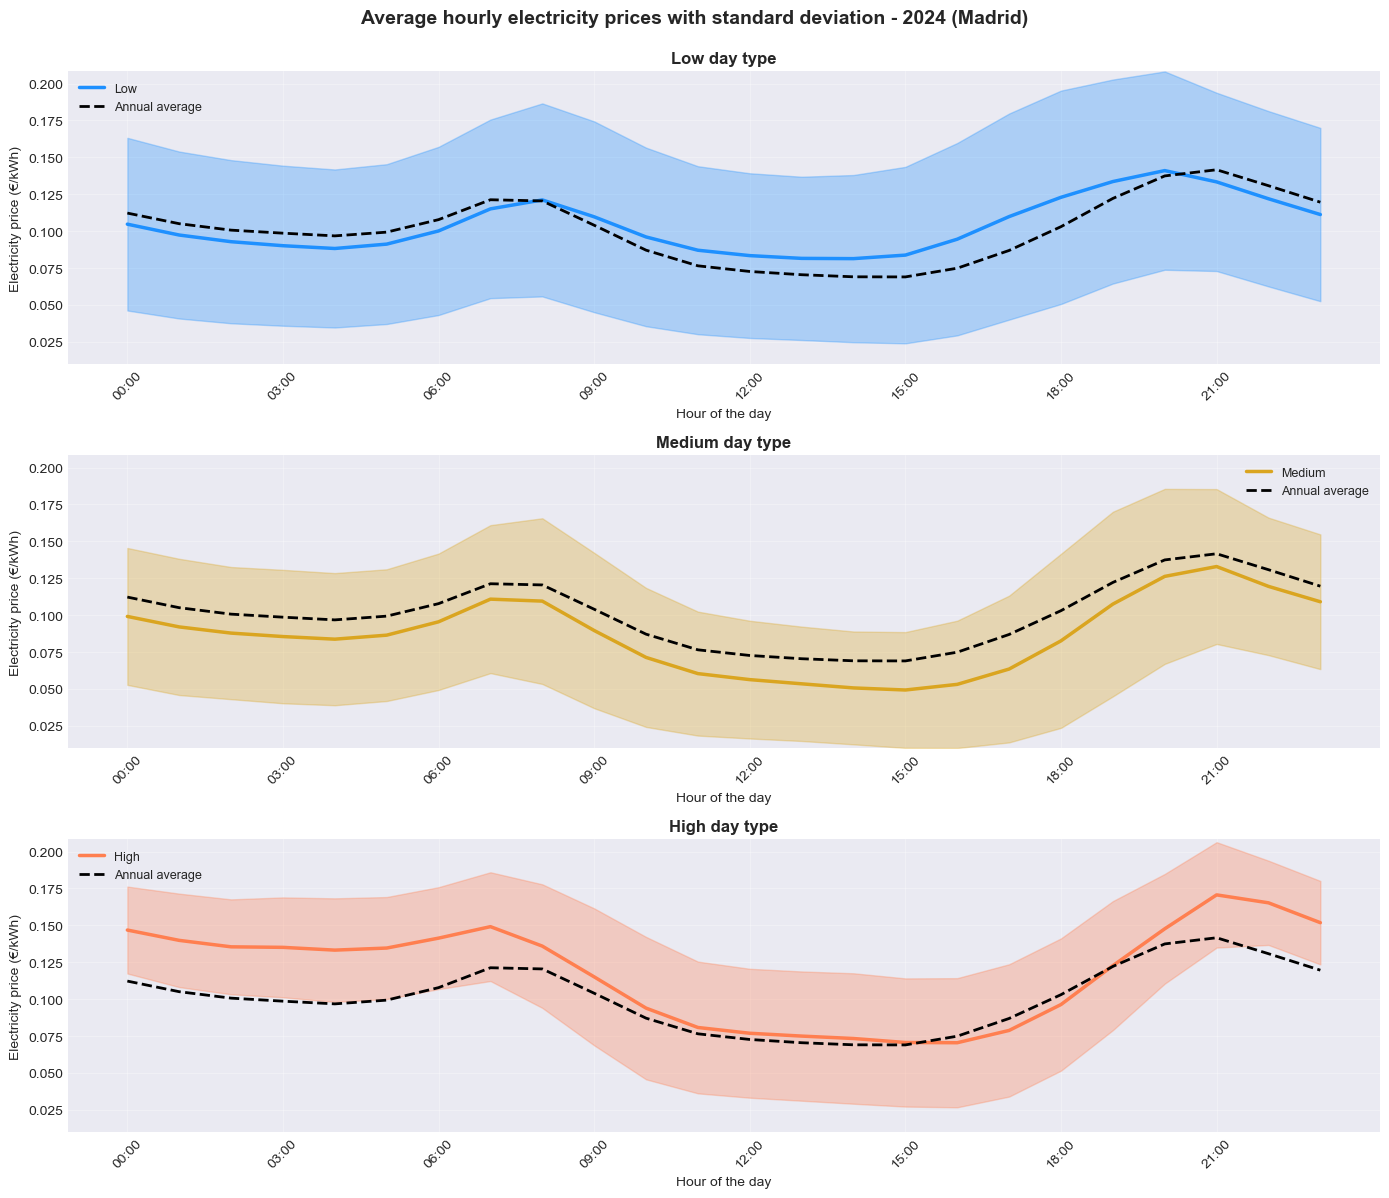

In [87]:
# Detailed view with standard deviation bands for averaged categories (so excluding 'worst_day')
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colors_avg = ['dodgerblue', 'goldenrod', 'coral']
day_types_avg = ['Low', 'Medium', 'High']

# Calculate standard deviations for each day type
clustered_prices_std = df_day_types.groupby('day_type').std(numeric_only=True)

# Calculate global y-axis limits
all_mins = []
all_maxs = []
for day_type in day_types_avg:
    mean_values = clustered_prices_expanded.loc[day_type].values
    std_values = clustered_prices_std.loc[day_type].values
    all_mins.append(np.min(mean_values - std_values))
    all_maxs.append(np.max(mean_values + std_values))

y_min = min(all_mins)
y_max = max(all_maxs)

for idx, day_type in enumerate(day_types_avg):
    ax = axes[idx]
    mean_values = clustered_prices_expanded.loc[day_type].values
    std_values = clustered_prices_std.loc[day_type].values
    
    # Plot the shaded area (mean ± std)
    ax.fill_between(range(24), 
                     mean_values - std_values, 
                     mean_values + std_values,
                     alpha=0.3, 
                     color=colors_avg[idx])
    
    # Plot the mean line
    ax.plot(range(24), mean_values, 
             linewidth=2.5, color=colors_avg[idx], label=day_type)
    
    # Plot the annual average
    ax.plot(range(24), average_hourly_price, 
             linewidth=2, color='black', linestyle='--', label='Annual average')
    
    ax.set_title(f'{day_type} day type', fontsize=12, fontweight='bold')
    ax.set_xlabel('Hour of the day', fontsize=10)
    ax.set_ylabel('Electricity price (€/kWh)', fontsize=10)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=45)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

fig.suptitle('Average hourly electricity prices with standard deviation - 2024 (Madrid)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()